# ROC analysis of an analysis pipeline

This notebook runs repeated simulations through an analysis pipeline and uses the
known ground truth to build a ROC curve, which shows how well the pipeline
controls false positives.

The pipeline settings are supplied through `model.pipeline_args`, which is handed
to `pipeline.set_all_options(...)`. Every entry is validated by the corresponding
**option variable** of the module it belongs to (see
`pyBrainAnalyzIR.dataclasses.options_variables`), so a typo or an out-of-range
value is reported immediately rather than producing a misleading ROC curve.

In [1]:
import sys
#sys.path.append('/Users/theodorehuppert/VSCode/pyNIRS_toolbox/pyNIRS_toolbox')

import pyBrainAnalyzIR.testing.channelROC as roc

import pyBrainAnalyzIR.testing.simData as simdata
import pyBrainAnalyzIR.pipelines.modules.preproccessing as prep
import pyBrainAnalyzIR.pipelines.modules.glm as stats


In [2]:
model=roc.ChannelROC()
model.data_simulation_function=simdata.Data
model.pipeline = roc.PipelineList([prep.intensity_opticaldensity,
                                    prep.mbll,
                                    prep.resample,
                                    stats.GLM])
model.data_simulation_args={'snr':10}  # These are passed to the simulation function
model.pipeline_args={'noise_model':'ar_irls','Fs':4,'ar_order':32} # These are set on the pipeline object

### Checking the pipeline settings

`pipeline_args` are only applied when `run()` is called. To confirm what the
pipeline will actually use - and to look up what each setting means - inspect the
options of the pipeline directly.

In [3]:
# apply the requested settings and show the resulting pipeline
model.pipeline.set_all_options(model.pipeline_args)
model.pipeline.show()

Calculate Optical Density:
Options:
None
Calculate Modified Beer-Lambert:
	Citation: Cope & Delpy:

Options:
	spectrum : prahl
	dpf      : [6, 6]
resample:
Options:
	Fs : 4
GLM Model:
	Citation: Barker, Jeffrey W., Ardalan Aarabi, and Theodore J. Huppert. Autoregressive model based algorithm for correcting motion and serially correlated errors in fNIRS. Biomedical optics express 4.8 (2013): 1366-1379:

Options:
	noise_model                   : ar_irls
	ar_order                      : 32
	max_jobs                      : 1
	basis_function                : <Gamma>
	Add_Short_Seperations         : False
	Short_Seperation_Max_Distance : 1.5 centimeter
	drift_order                   : 0
	verbose                       : True


In [4]:
# look up what an individual setting does, including its default and valid range
model.pipeline.get_option('ar_order').print_help()
print()
model.pipeline.get_option('Fs').print_help()

ar_order: 32
  Autoregressive model order
  Maximum order of the autoregressive noise model. Only used when noise_model='ar_irls'. A common choice is 4x the sample rate.
  (default: 30)

Fs: 4
  Target sampling frequency (Hz)
  The data are resampled to this sampling rate. Must be strictly positive; values well below the original rate will low-pass the data.
  (default: 4)


Invalid settings are rejected when they are applied, which catches mistakes
before a long batch of simulations is started.

In [5]:
for bad_args in ({'noise_model': 'ar-irls'},   # typo: the valid name is 'ar_irls'
                 {'Fs': 0},                   # the sample rate must be positive
                 {'ar_order': 2.5}):          # the model order must be an integer
    try:
        model.pipeline.set_all_options(bad_args)
    except ValueError as err:
        print('rejected ->', err)

# restore the settings we actually want to run
model.pipeline.set_all_options(model.pipeline_args)

rejected -> noise_model: value must be one of ['ols', 'ar_irls', 'wls', 'gls', 'rls'] (got 'ar-irls')
rejected -> Fs: value must be > 0 (got 0)
rejected -> ar_order: value must be an integer (got 2.5)


In [6]:
model.run(10)
# run incremental number of simulations


Interation 0


100%|██████████| 16/16 [00:00<00:00, 36.86it/s]


Interation 1


100%|██████████| 16/16 [00:00<00:00, 36.05it/s]


Interation 2


...

100%|██████████| 16/16 [00:00<00:00, 34.83it/s]


Interation 8


100%|██████████| 16/16 [00:00<00:00, 36.76it/s]


Interation 9


100%|██████████| 16/16 [00:00<00:00, 35.76it/s]


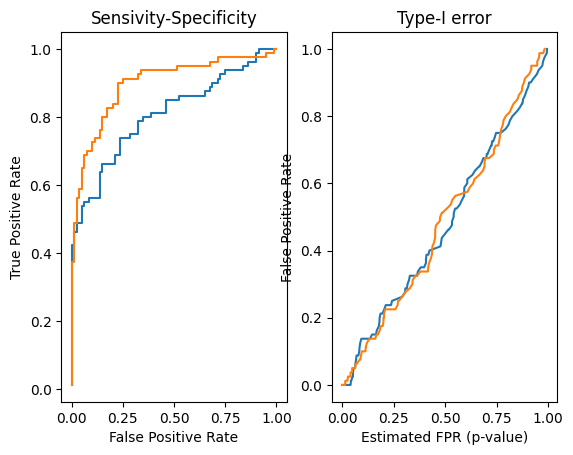

In [7]:
model.draw()

### Comparing two pipelines

Re-running the same simulation with a different `noise_model` shows the effect of
the estimator on the false-positive control. Only the options that are named in
`pipeline_args` are changed; every other option keeps the default defined by its
module.

Interation 0


100%|██████████| 16/16 [00:00<00:00, 1607.05it/s]


Interation 1


100%|██████████| 16/16 [00:00<00:00, 1576.03it/s]


Interation 2


...

100%|██████████| 16/16 [00:00<00:00, 1561.91it/s]


Interation 8


100%|██████████| 16/16 [00:00<00:00, 1567.56it/s]


Interation 9


100%|██████████| 16/16 [00:00<00:00, 1159.33it/s]


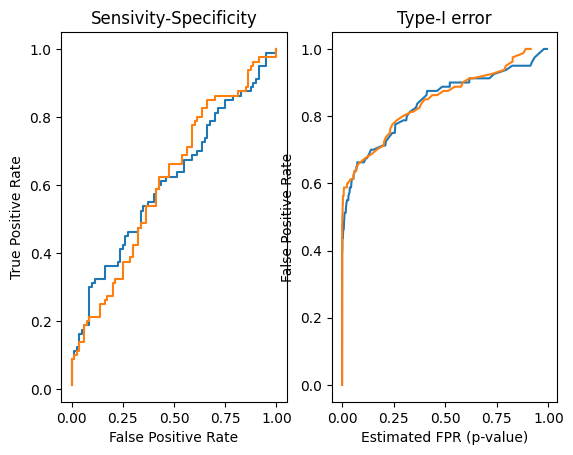

In [8]:
model=roc.ChannelROC()
model.pipeline = roc.PipelineList([prep.intensity_opticaldensity,
                                    prep.mbll,
                                    prep.resample,
                                    stats.GLM])
model.data_simulation_args={'snr':10}
model.pipeline_args={'noise_model':'ols','Fs':4}
model.run(10)
model.draw()